<a href="https://colab.research.google.com/github/deepanshuchauhanx1/AI-Traffic-Flow-Optimizer/blob/main/notebooks/01_dataset_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git clone https://github.com/deepanshuchauhanx1/AI-Traffic-Flow-Optimizer .git

Cloning into '.git'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 26 (delta 5), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 6.35 MiB | 13.18 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

In [5]:
!pip install kaggle

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ganeshmohane/indian-emergency-vehicles-dataset")

print("Path to dataset files:", path)

100%|██████████| 195M/195M [00:05<00:00, 37.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ganeshmohane/indian-emergency-vehicles-dataset/versions/1


In [7]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/ganeshmohane/indian-emergency-vehicles-dataset/versions/1"

os.listdir(dataset_path)

['valid', 'README.roboflow.txt', 'test', 'train']

In [9]:
train = pd.read_csv(dataset_path + "/train/_classes.csv")
valid = pd.read_csv(dataset_path + "/valid/_classes.csv")
test = pd.read_csv(dataset_path + "/test/_classes.csv")
print(f"Shape of train: {train.shape}, valid: {valid.shape}, test: {test.shape}")

Shape of train: (8277, 8), valid: (624, 8), test: (476, 8)


In [10]:
train.columns = train.columns.str.strip()
valid.columns = valid.columns.str.strip()
test.columns = test.columns.str.strip()

print(train.columns)

Index(['filename', 'TwoWheelers', 'ambulance', 'auto-rikshaw', 'bus', 'car',
       'firetruck', 'police vehicle'],
      dtype='object')


In [11]:
classes = [
    "TwoWheelers",
    "ambulance",
    "auto-rikshaw",
    "bus",
    "car",
    "firetruck",
    "police vehicle"
]
def get_label(row):
    for c in classes:
        if row[c] == 1:
            return c
    return "unknown"

train["label"] = train.apply(get_label, axis=1)
valid["label"] = valid.apply(get_label, axis=1)
test["label"] = test.apply(get_label, axis=1)

In [14]:
train["split"] = "train"
valid["split"] = "valid"
test["split"] = "test"

df = pd.concat([train, valid, test], ignore_index=True)

In [15]:
df

,filename,TwoWheelers,ambulance,auto-rikshaw,bus,car,firetruck,police vehicle,label,split
0,129_jpg.rf.84859d4fc5818dc50d1f96b88b7efc36.jpg,0,0,0,0,0,1,0,firetruck,train
1,new-delhi-india-june-17-260nw-1758724742_jpg.r...,0,1,0,0,0,0,0,ambulance,train
2,ambulance-395-_jpg.rf.84890f639c23d72eba234cd0...,0,0,0,0,0,0,0,unknown,train
3,13_jpg.rf.8491319430ac3431e84d5c33468b30ac.jpg,0,0,0,0,0,0,0,unknown,train
4,ambulance-190-_jpg.rf.8499adab18f6dc139f642a2b...,0,0,0,0,0,0,0,unknown,train
...,...,...,...,...,...,...,...,...,...,...
9372,ambulance-408-_jpg.rf.fcd558f58c3b1186d256a745...,0,0,0,0,0,0,0,unknown,test
9373,15_jpg.rf.fc97869d7c1933a273f0f2ad578a28c7.jpg,0,0,0,0,0,1,0,firetruck,test
9374,Ambulance_used_by_Narayana_Health_Group-_India...,0,1,0,0,0,0,0,ambulance,test
9375,ambulance-348-_jpg.rf.fcbefc2fdb28c4b1214d9862...,0,0,0,0,0,0,0,unknown,test


In [16]:
print("Total Images:", len(df))
print(df["label"].value_counts())

Total Images: 9377
label
unknown           3132
ambulance         2742
police vehicle    1270
firetruck         1152
car                456
bus                257
TwoWheelers        252
auto-rikshaw       116
Name: count, dtype: int64


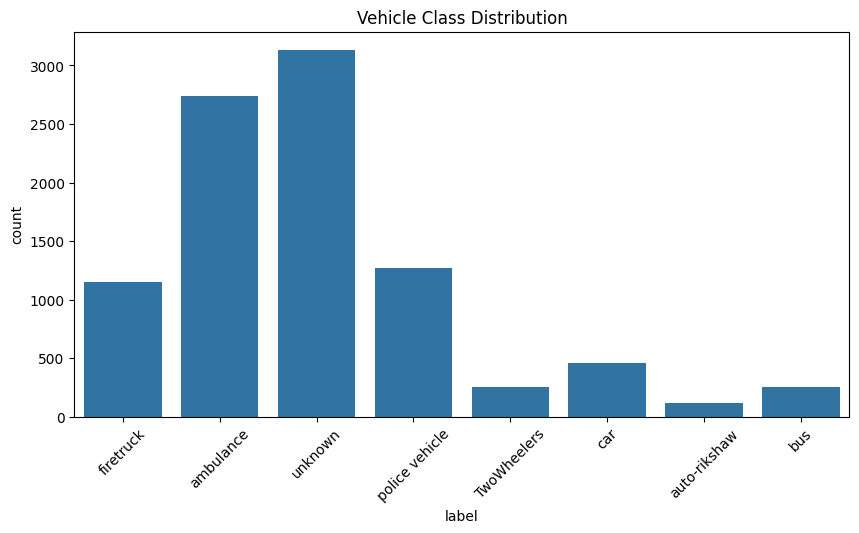

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="label")
plt.xticks(rotation=45)
plt.title("Vehicle Class Distribution")
plt.show()

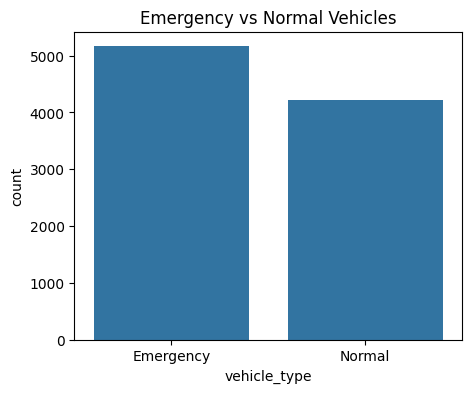

In [19]:
emergency = ["ambulance","firetruck","police vehicle"]

df["vehicle_type"] = df["label"].apply(
    lambda x: "Emergency" if x in emergency else "Normal"
)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="vehicle_type")
plt.title("Emergency vs Normal Vehicles")
plt.show()

In [20]:
percent = df["label"].value_counts(normalize=True) * 100
print(percent)

label
unknown           33.400874
ambulance         29.241762
police vehicle    13.543777
firetruck         12.285379
car                4.862963
bus                2.740749
TwoWheelers        2.687427
auto-rikshaw       1.237069
Name: proportion, dtype: float64


In [22]:
df = df[df["label"] != "unknown"]
df["label"].value_counts(normalize=True) * 100

,proportion
label,
ambulance,43.907126
police vehicle,20.336269
firetruck,18.446757
car,7.301841
bus,4.115292
TwoWheelers,4.035228
auto-rikshaw,1.857486


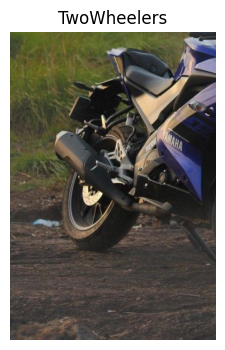

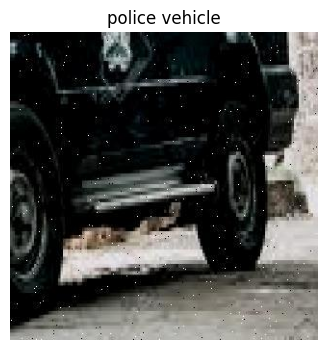

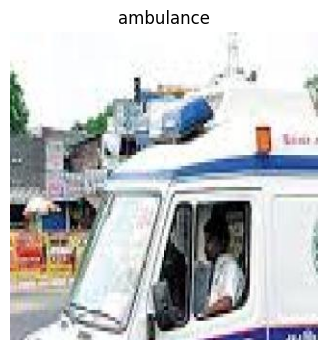

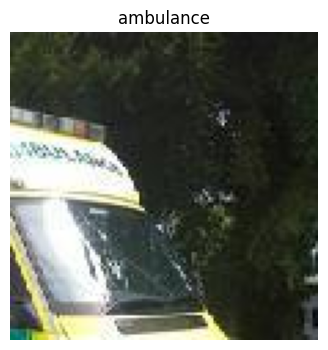

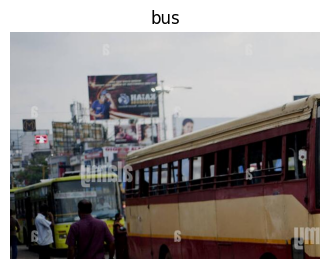

In [27]:
sample = train.sample(5)

for i,row in sample.iterrows():

    img_path = dataset_path + "/train/" + row["filename"]
    img = cv2.imread(img_path)

    if img is None:
        print("Image not found:", img_path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

In [28]:
sizes = []

for file in train["filename"][:200]:  # sample
    path = dataset_path + "/train/" + file
    img = cv2.imread(path)

    if img is not None:
        h,w,_ = img.shape
        sizes.append((w,h))

sizes = pd.DataFrame(sizes, columns=["width","height"])

sizes.describe()

,width,height
count,200.000000,200.000000
mean,354.330000,315.420000
std,196.623588,121.757084
min,112.000000,84.000000
25%,320.000000,320.000000
50%,320.000000,320.000000
75%,320.000000,320.000000
max,1000.000000,1000.000000


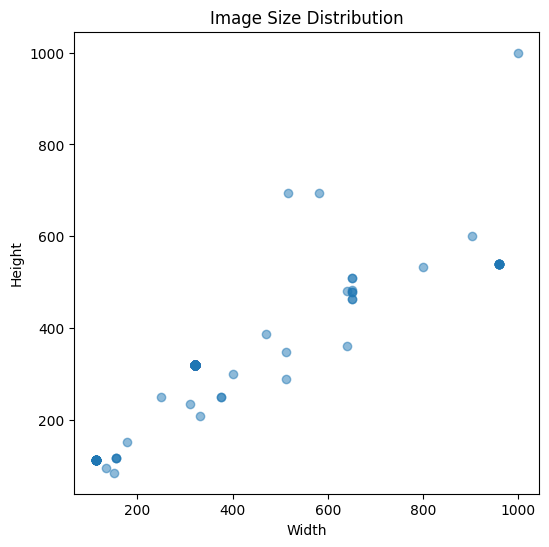

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(sizes["width"], sizes["height"], alpha=0.5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.show()

In [30]:
sizes["ratio"] = sizes["width"] / sizes["height"]

print(sizes["ratio"].describe())

count    200.000000
mean       1.094048
std        0.226094
min        0.743885
25%        1.000000
50%        1.000000
75%        1.000000
max        1.785714
Name: ratio, dtype: float64


In [31]:
train[classes].sum(axis=1).value_counts()

,count
1,5239
0,2765
2,162
3,90
4,15
5,6
